# 01 · Обзор данных IT-поддержки аэропорта

**Проект:** аналитика службы технической поддержки аэропорта Домодедово.

**Данные:** синтетические (сгенерированы `data/synthetic_data_generator.py`), но смоделированы так, чтобы повторять поведение реальной службы: суточные пики под волны рейсов, недельная и годовая сезонность, старение оборудования, нарушения SLA под нагрузкой и влияние критических инцидентов на рейсы.

**Период:** 2 полных года (2024–2025). В этом ноутбуке знакомимся с набором данных, проверяем качество и смотрим, как распределена нагрузка во времени.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent / 'src'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from analysis import load_data, NAVY, STEEL, SKY, ORANGE, RED, GREEN, WD_ORDER
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.grid': True,
                     'grid.color': '#e8ecf0', 'axes.unicode_minus': False})
t, flights, sla, systems, agents = load_data()
print('Обращений:', len(t), '| период:', t.created_at.min().date(), '—', t.created_at.max().date())
t.head(3)

Обращений: 33309 | период: 2024-01-01 — 2025-12-31


,ticket_id,created_at,first_response_at,resolved_at,status,priority,category,system,criticality,is_critical_for_flights,zone,channel,reporter_role,team,agent_id,...,sla_breached,reopened,service_downtime_min,delayed_flights,csat,date,hour,weekday,weekday_name,month,year,ym,resolution_hours,is_closed,is_open
0,DME-000001,2024-01-01 00:10:07,2024-01-01 00:24:07,2024-01-01 00:51:07,Закрыт,P2,Периферия,Рабочие станции (АРМ),Низкая,False,Служебные зоны,Телефон,Администрация аэропорта,1-я линия поддержки,AG-105,...,False,False,0,0,5.0,2024-01-01,0,0,Пн,1,2024,2024-01,0.683333,True,False
1,DME-000002,2024-01-01 00:24:48,2024-01-01 00:32:48,2024-01-01 00:50:48,Закрыт,P3,Периферия,Принтеры посадочных талонов,Средняя,True,Зона регистрации,Телефон,Авиакомпания,1-я линия поддержки,AG-102,...,False,False,0,0,5.0,2024-01-01,0,0,Пн,1,2024,2024-01,0.433333,True,False
2,DME-000003,2024-01-01 02:07:42,2024-01-01 02:18:42,2024-01-01 05:25:42,Закрыт,P3,Оборудование,Рабочие станции (АРМ),Низкая,False,ЦОД и серверная,Телефон,Операционный центр,Полевая служба,AG-126,...,False,False,0,0,4.0,2024-01-01,2,0,Пн,1,2024,2024-01,3.300000,True,False


## Состав данных

Главная таблица — журнал обращений `tickets` (одна строка = одно обращение). Ключевые поля: время создания/реакции/решения, приоритет (P1–P4), категория, затронутая система, зона аэропорта, канал, команда и сотрудник, метрики SLA, флаг переоткрытия, простой и число задержанных рейсов, оценка CSAT.

In [2]:
print('Размерность:', t.shape)
print('\nСтатусы обращений:')
print(t.status.value_counts())
print('\nПропуски по ключевым полям (ожидаемы у открытых/отменённых и по CSAT):')
print(t[['resolved_at','resolution_min','csat']].isna().sum())

Размерность: (33309, 36)

Статусы обращений:
status
Закрыт                   32756
Отменён                    430
В работе                    58
Назначен                    42
Ожидание пользователя       23
Name: count, dtype: int64

Пропуски по ключевым полям (ожидаемы у открытых/отменённых и по CSAT):
resolved_at         553
resolution_min      553
csat              18576
dtype: int64


## Динамика объёма и рост год к году

Смотрим число обращений по месяцам. Синим — 2024, оранжевым — 2025.

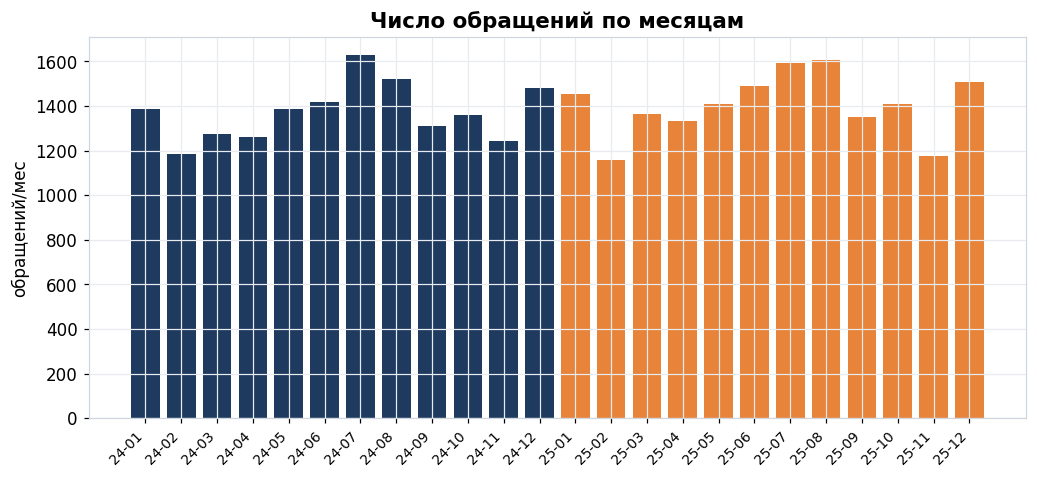

Средний объём: 2024 = 1372/мес, 2025 = 1404/мес, рост 2.4%


In [3]:
m = t.groupby('ym').size()
avg24 = m[[i.startswith('2024') for i in m.index]].mean()
avg25 = m[[i.startswith('2025') for i in m.index]].mean()
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [NAVY if x.startswith('2024') else ORANGE for x in m.index]
ax.bar(range(len(m)), m.values, color=colors)
ax.set_xticks(range(len(m))); ax.set_xticklabels([x[2:] for x in m.index], rotation=45, ha='right', fontsize=9)
ax.set_title('Число обращений по месяцам'); ax.set_ylabel('обращений/мес')
plt.show()
print(f'Средний объём: 2024 = {avg24:.0f}/мес, 2025 = {avg25:.0f}/мес, рост {avg25/avg24*100-100:.1f}%')

## Когда приходят обращения

Тепловая карта «час × день недели» (среднее число обращений в час). Хорошо видны две волны — утренняя и вечерняя, совпадающие с банками рейсов.

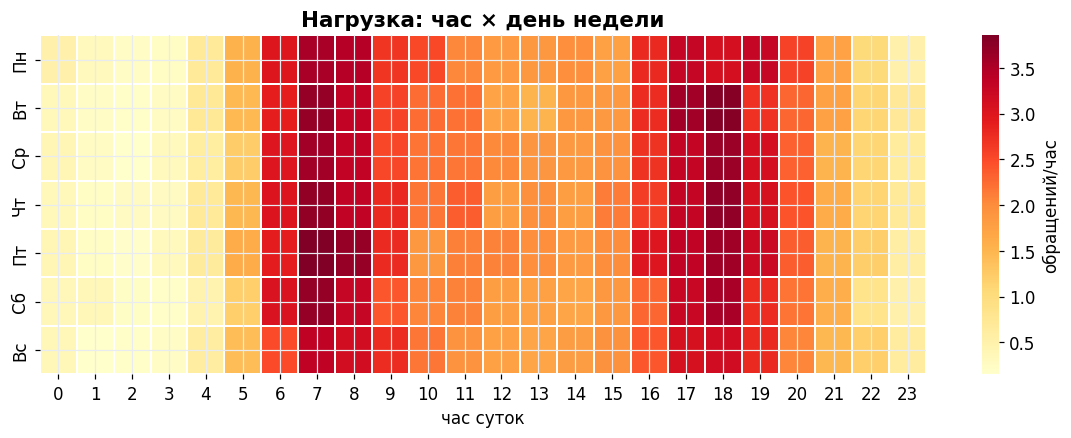

In [4]:
piv = t.pivot_table(index='weekday_name', columns='hour', values='ticket_id', aggfunc='count').reindex(WD_ORDER)
nd = t.groupby('weekday_name')['date'].nunique().reindex(WD_ORDER)
piv_avg = piv.div(nd, axis=0)
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(piv_avg, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'обращений/час'}, linewidths=.3, linecolor='white')
ax.set_title('Нагрузка: час × день недели'); ax.set_xlabel('час суток'); ax.set_ylabel('')
plt.show()

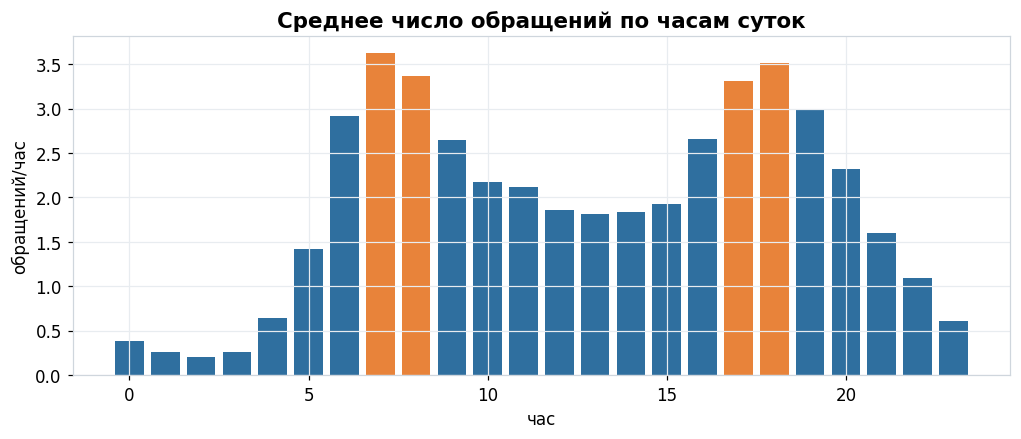

Пиковые часы (max нагрузка): [7, 18, 8, 17]


In [5]:
h = t.groupby('hour').size() / t.date.nunique()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(h.index, h.values, color=[ORANGE if x in [7,8,17,18] else STEEL for x in h.index])
ax.set_title('Среднее число обращений по часам суток'); ax.set_xlabel('час'); ax.set_ylabel('обращений/час')
plt.show()
print('Пиковые часы (max нагрузка):', list(h.sort_values(ascending=False).head(4).index))

### Выводы блока

- Нагрузка стабильно растёт год к году вслед за пассажиропотоком.
- Обращения приходят двумя волнами — **утро 06:00–09:00** и **вечер 17:00–19:00**.
- Будни заметно нагруженнее выходных.

Дальше (ноутбук 02) разберём, какие системы и категории создают нагрузку и как служба справляется с SLA.